In [1]:
from diffusers import DDPMScheduler, UNet2DModel, UNet2DConditionModel
import torch
import os
import random
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
from tqdm import tqdm
import torchvision.models as models
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
from transformers import CLIPTokenizer, CLIPTextModel
from torch.cuda.amp import autocast, GradScaler  # Add these imports for mixed precision
from torch.optim.lr_scheduler import CosineAnnealingLR, OneCycleLR, ReduceLROnPlateau  # Add scheduler imports

In [2]:
IMG_PATH = './img/img_align_celeba/img_align_celeba'
# IMG_PATH = '/kaggle/input/celeba-dataset/img_align_celeba/img_align_celeba'

In [3]:
max_timesteps = 100

noise_scheduler = DDPMScheduler(num_train_timesteps=max_timesteps,
                                beta_start=0.0001,
                                beta_end=0.1,
                                )

In [24]:
# function to load a random image from ./img/img_align_celeba/img_align_celeba
# and return it as a tensor
def load_random_img():
    img_name = random.choice(os.listdir(IMG_PATH))
    img = Image.open(os.path.join(IMG_PATH, img_name)).convert('RGB')
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5])
    ])
    return transform(img).unsqueeze(0)

In [25]:
def load_img(img_path):
    img = Image.open(img_path).convert('RGB')
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5])
    ])
    return transform(img).unsqueeze(0)

In [4]:
def denormalize(image):
    image = image.squeeze(0).permute(1, 2, 0).numpy()
    image = image * 0.5 + 0.5
    return image.clip(0, 1)

In [27]:
def plot_images(timesteps, images):
    img_height, img_width = images[0].shape[:2]
    num_images = len(timesteps)
    num_cols = min(num_images, 10)
    num_rows = (num_images + num_cols - 1) // num_cols
    
    fig, axs = plt.subplots(num_rows, num_cols, figsize=(img_width * num_cols / 100, img_height * num_rows / 100))
    axs = axs.flatten() if num_rows > 1 else [axs]
    
    for i, ax in enumerate(axs):
        if i < num_images:
            ax.imshow(images[i])
            ax.axis('off')
            ax.set_title(f'Timestep {timesteps[i]}')
        else:
            ax.axis('off')
    plt.show()

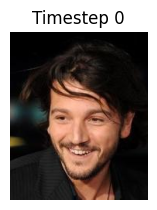

In [28]:
image = load_random_img()
plot_images([0], [denormalize(image)])

In [29]:
img_shape = image.shape
img_shape

torch.Size([1, 3, 218, 178])

In [30]:
timesteps = torch.arange(max_timesteps)
noise = torch.randn(img_shape)

In [31]:
noisy_images = noise_scheduler.add_noise(image, noise, timesteps)

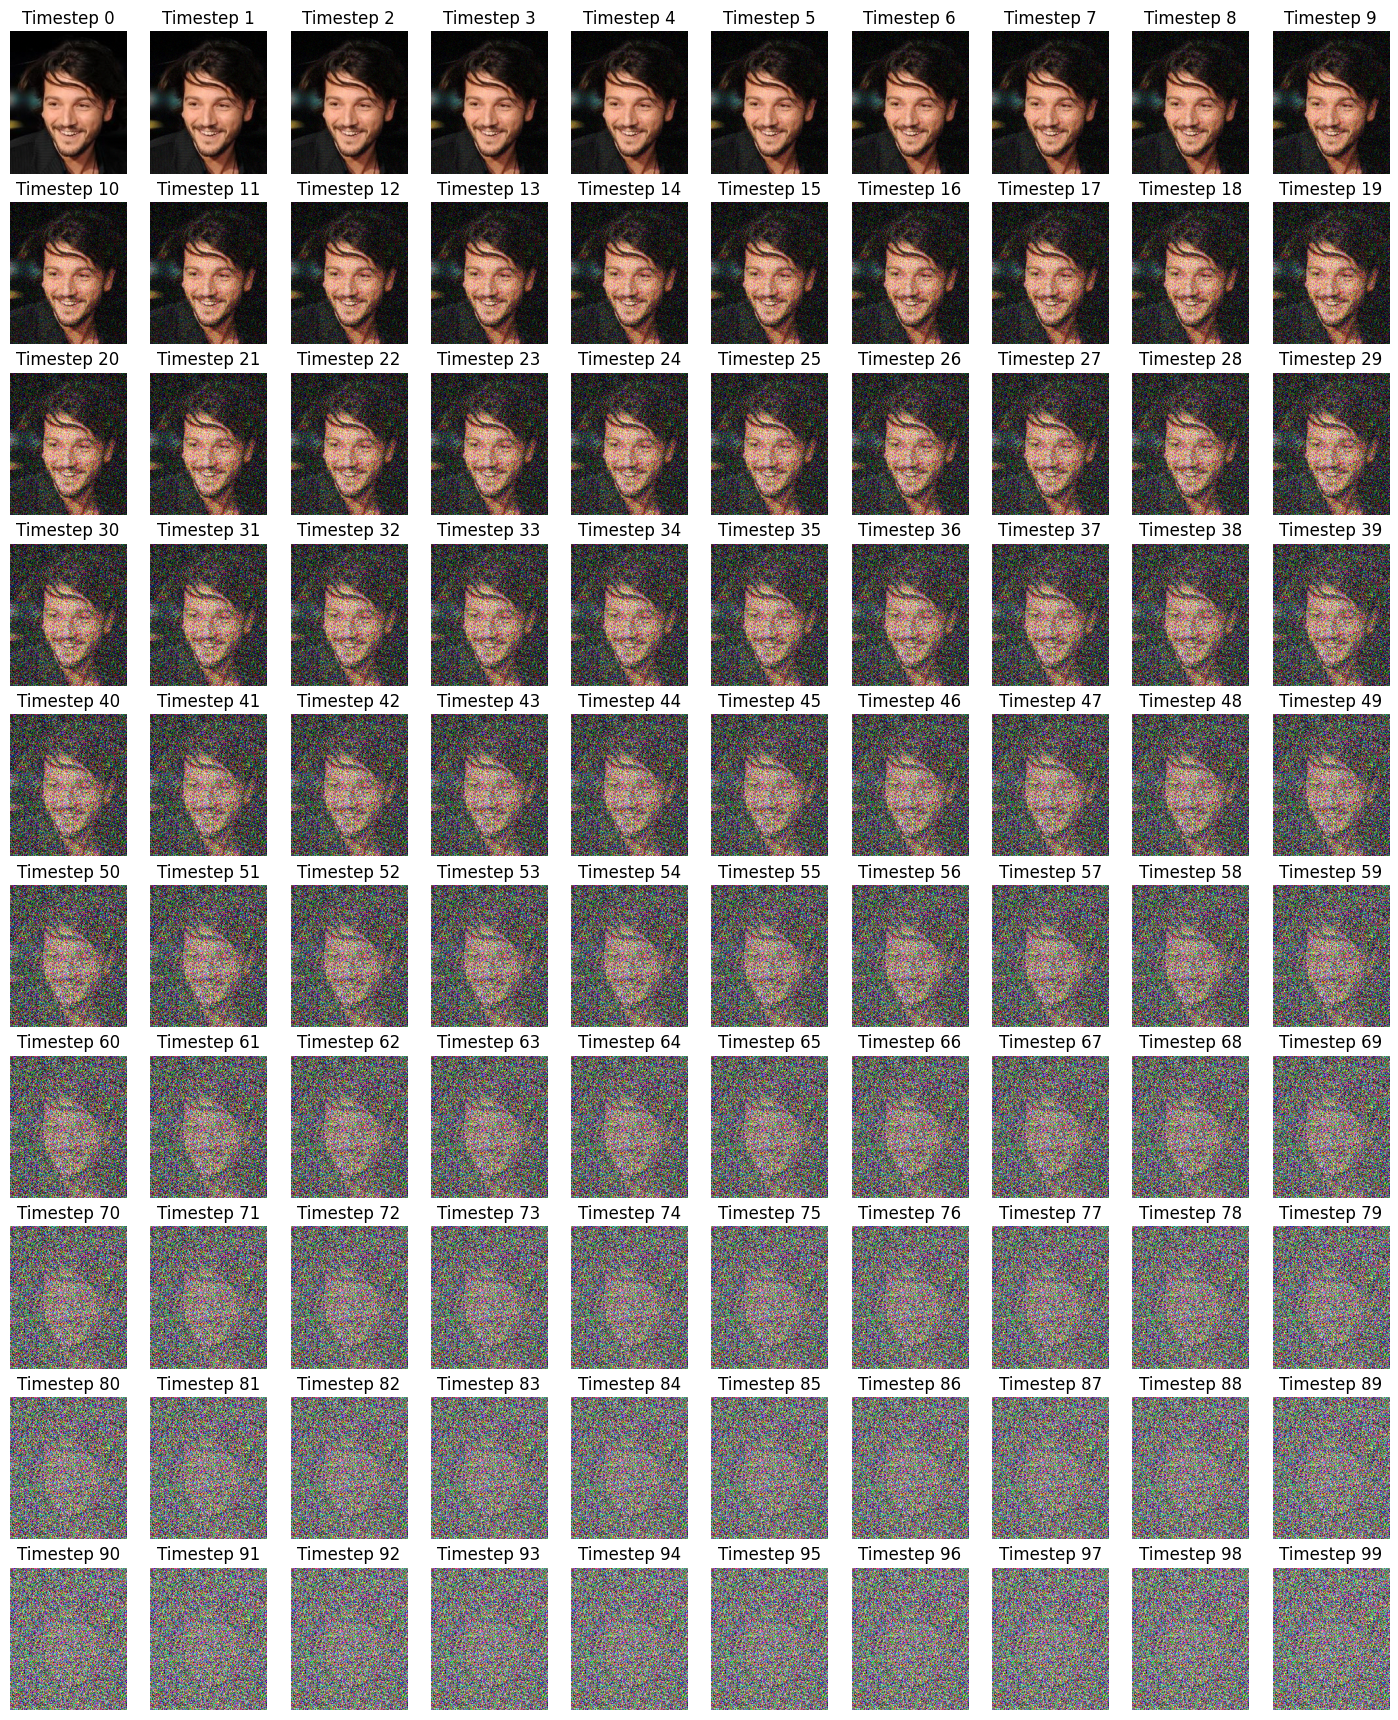

In [32]:
plot_images(timesteps, [denormalize(img) for img in noisy_images])

---

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [6]:
device

device(type='cuda')

In [6]:
# Transform to [C, H, W] format
transform = transforms.Compose([
    # transforms.ToPILImage(),
    transforms.Resize((128, 128)),
    # transforms.RandomHorizontalFlip(),
    # transforms.RandomRotation(30),
    # transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),  # converts [H, W, C] from PIL to [C, H, W] Tensor
    transforms.Normalize([0.5], [0.5])
])

# Create a dataset
dataset = ImageFolder(
root="./img/img_align_celeba",
    transform=transform
)

# train_size = int(0.9 * len(dataset))
# val_size = int(0.05 * len(dataset))
# test_size = len(dataset) - train_size - val_size
# train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, val_size, test_size])

# # Create dataloaders
# train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
# val_loader = DataLoader(val_dataset, batch_size=32, shuffle=True)
# test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

dataloader = DataLoader(dataset, batch_size=256, shuffle=True, num_workers=4)

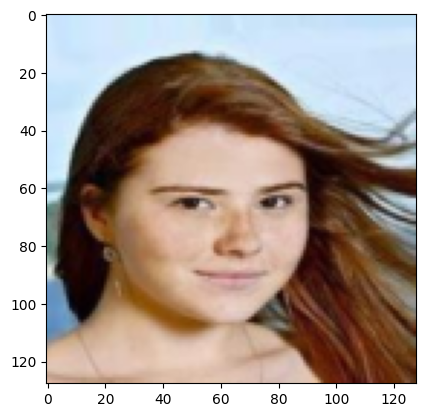

In [35]:
image = next(iter(dataloader))[0][0]
image.shape

plt.imshow(denormalize(image))

In [7]:
from SpatialVAE import SpatialVAE

vae = SpatialVAE(latent_channels=3)

In [9]:
vae = torch.load("vae.pth").to(device)

/tmp/ipykernel_1299/599483638.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  vae = torch.load("vae.pth").to(device)


In [36]:
torch.save(vae, "vae.pth")

In [ ]:
from SpatialVAE import train_vae

train_vae(vae, dataloader, num_epochs=15, learning_rate=0.001)

100%|██████████| 792/792 [03:37<00:00,  3.64it/s]


Epoch 1/15, Loss: 0.030120651150649092


100%|██████████| 792/792 [03:47<00:00,  3.47it/s]


Epoch 2/15, Loss: 0.011729855139768033


100%|██████████| 792/792 [03:57<00:00,  3.34it/s]


...

Epoch 7/15, Loss: 0.008647888030438223


100%|██████████| 792/792 [04:02<00:00,  3.27it/s]


Epoch 8/15, Loss: 0.008515877415769441


 37%|███▋      | 291/792 [01:30<02:35,  3.21it/s]


KeyboardInterrupt: 

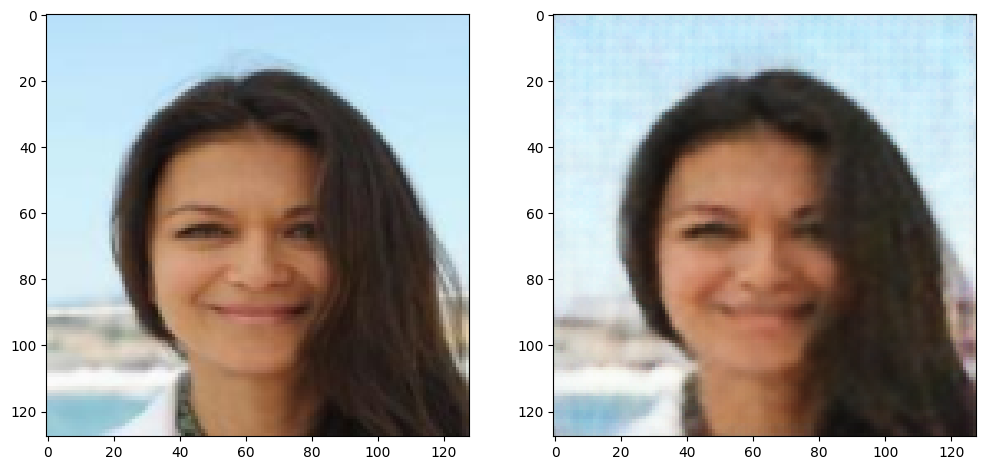

In [40]:
image = next(iter(dataloader))[0][0].to(device)
# image = transform(transforms.ToPILImage()(load_img("./photo_2025-02-13_16-39-18.jpg")[0])).to(device)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(denormalize(image.cpu()))

plt.subplot(1, 2, 2)

vae.eval()
recon, _, _ = vae(image.unsqueeze(0))
plt.imshow(denormalize(recon.detach().cpu()))

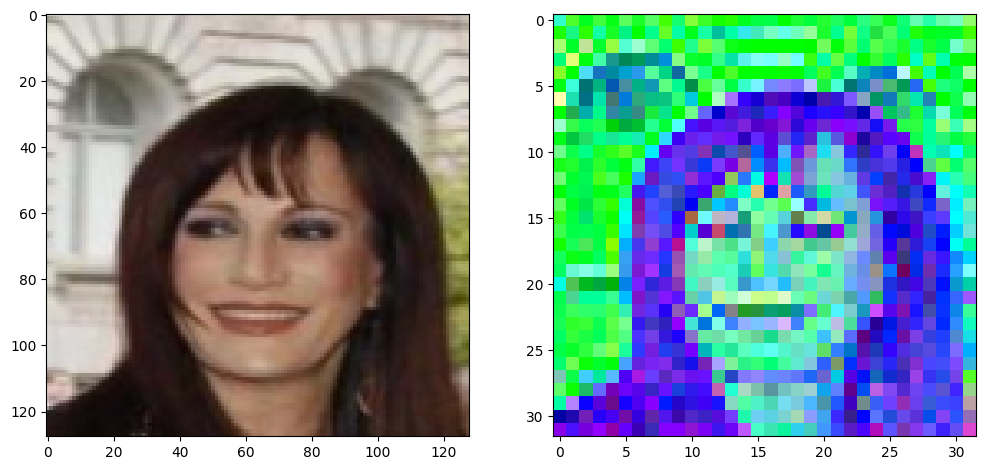

In [41]:
image = next(iter(dataloader))[0][0].to(device)

encoded = vae.reparameterize(*vae.encode(image.unsqueeze(0)))

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(denormalize(image.cpu()))

plt.subplot(1, 2, 2)
plt.imshow(denormalize(encoded.detach().cpu()))

In [35]:
model = UNet2DModel(
    sample_size=32,          # Input image size (32x32)
    in_channels=3,           # Input channels (RGB)
    out_channels=3,          # Output channels (RGB)
    layers_per_block=2,      # Keep it simple with 1 layer per block
    block_out_channels=(32, 64, 64, 128),  # Channel progression (lightweight)
    # down_block_types=(
    #     "DownBlock2D",       # Standard downsampling block
    #     "DownBlock2D",
    #     "DownBlock2D",
    #     "AttnDownBlock2D",   # Attention block
    # ),
    # up_block_types=(
    #     "AttnUpBlock2D",     # Attention block
    #     "UpBlock2D",         # Standard upsampling block
    #     "UpBlock2D",
    #     "UpBlock2D",
    # ),
).to(device)

In [9]:
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

NameError: name 'model' is not defined

In [ ]:
from train import train_one_epoch_unconditional

losses = train_one_epoch_unconditional(model, vae, optimizer, dataloader, noise_scheduler, max_timesteps, device)

100%|██████████| 792/792 [35:18<00:00,  2.68s/it]


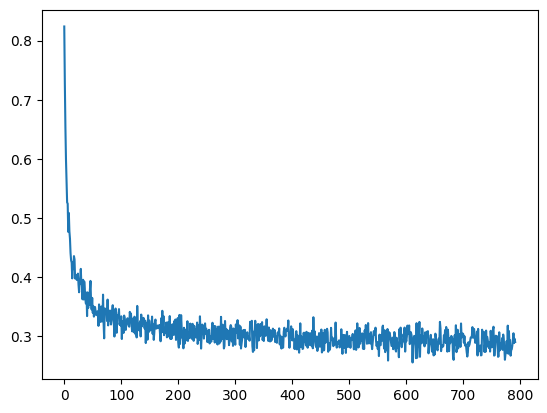

In [39]:
plt.plot(losses)

In [44]:
torch.save(model, "unet.pth")

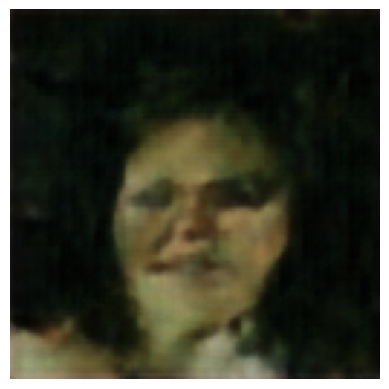

In [43]:
target_img_shape = (3, 32, 32)

generator = torch.Generator(device=device).manual_seed(42)

image = torch.randn((1, *target_img_shape), device=device) #, generator=generator)
timesteps = torch.arange(0, noise_scheduler.timesteps.max(), device=device)

new_images = []

for idx, t in enumerate(reversed(timesteps)):
    with torch.no_grad():
        model_output = model(image, t).sample

    image = noise_scheduler.step(model_output, t, image, generator=generator).prev_sample

plt.imshow(denormalize(vae.decode(image).detach().cpu()))
plt.axis('off')
plt.show()

---

In [10]:
df_attr = pd.read_csv('./img/list_attr_celeba.csv')

In [5]:
df_attr.columns

Index(['image_id', '5_o_Clock_Shadow', 'Arched_Eyebrows', 'Attractive',
       'Bags_Under_Eyes', 'Bald', 'Bangs', 'Big_Lips', 'Big_Nose',
       'Black_Hair', 'Blond_Hair', 'Blurry', 'Brown_Hair', 'Bushy_Eyebrows',
       'Chubby', 'Double_Chin', 'Eyeglasses', 'Goatee', 'Gray_Hair',
       'Heavy_Makeup', 'High_Cheekbones', 'Male', 'Mouth_Slightly_Open',
       'Mustache', 'Narrow_Eyes', 'No_Beard', 'Oval_Face', 'Pale_Skin',
       'Pointy_Nose', 'Receding_Hairline', 'Rosy_Cheeks', 'Sideburns',
       'Smiling', 'Straight_Hair', 'Wavy_Hair', 'Wearing_Earrings',
       'Wearing_Hat', 'Wearing_Lipstick', 'Wearing_Necklace',
       'Wearing_Necktie', 'Young'],
      dtype='object')

In [11]:
from CelebaWithAttributes import CelebAWithAttributes

dataset_attr = CelebAWithAttributes(
    img_dir='./img/img_align_celeba/img_align_celeba',
    attr_csv='./img/list_attr_celeba.csv',
    transform=transform
)

dataloader_attr = DataLoader(dataset_attr, batch_size=128, shuffle=True, num_workers=4)

In [12]:
# Load the pre-trained CLIP tokenizer and text model
clip_tokenizer = CLIPTokenizer.from_pretrained("openai/clip-vit-base-patch32")
clip_text_encoder = CLIPTextModel.from_pretrained("openai/clip-vit-base-patch32").to(device)

In [ ]:
unet_cond = UNet2DConditionModel(
    sample_size=32,
    in_channels=3,
    out_channels=3,
    layers_per_block=2,
    block_out_channels=(64, 128, 256, 512),
    down_block_types=(
        "DownBlock2D",
        "DownBlock2D",
        "CrossAttnDownBlock2D",  # Cross-attention block
        "CrossAttnDownBlock2D",  # Cross-attention block
    ),
    up_block_types=(
        "CrossAttnUpBlock2D",    # Cross-attention block
        "CrossAttnUpBlock2D",
        "UpBlock2D",
        "UpBlock2D",
    ),
    cross_attention_dim=512,  # Dimension of the text embedding
).to(device)

In [13]:
from train import estimate_loss, train_one_epoch_with_text, get_clip_text_embedding

all_losses = []
best_loss = float('inf')

In [16]:
optimizer = torch.optim.AdamW(unet_cond.parameters(), lr=1e-3)

In [ ]:
losses = train_one_epoch_with_text(unet_cond, vae, optimizer, dataloader_attr)
plt.plot(losses)

 83%|████████▎ | 1317/1583 [2:29:04<30:06,  6.79s/it]  


KeyboardInterrupt: 

In [28]:
torch.save(unet_cond, "unet_cond.pth")

In [14]:
def generate_images_with_text(unet, vae, text, num_images=1, guidance_scale=3.0):
    """
    Generate images conditioned on text using the diffusion model with classifier-free guidance.
    
    Args:
        unet (torch.nn.Module): The diffusion model.
        vae (torch.nn.Module): The VAE that decodes latents into images.
        text (str): The text to condition on.
        num_images (int): Number of images to generate.
        guidance_scale (float): Scale for classifier-free guidance (1.0 means no guidance)
    
    Returns:
        list: List of generated images as numpy arrays.
    """
    unet.eval()
    vae.eval()
    
    # Get text embedding for conditioning
    text_embedding = get_clip_text_embedding([text] * num_images, clip_tokenizer, clip_text_encoder, device).to(device)
    
    # For classifier-free guidance, we also need unconditional embedding (empty string)
    if guidance_scale > 1.0:
        uncond_embedding = get_clip_text_embedding([""] * num_images, clip_tokenizer, clip_text_encoder, device).to(device)
    
    # Initialize with random noise
    latents = torch.randn((num_images, 3, 32, 32), device=device)
    
    # Use autocast for mixed precision during inference
    with autocast():
        # Diffusion process (iterating from noise to image)
        for t in tqdm(reversed(range(max_timesteps)), desc="Generating images"):
            # Convert timestep to tensor
            timestep = torch.tensor([t] * num_images, device=device)
            
            with torch.no_grad():
                if guidance_scale > 1.0:
                    # Predict noise with conditional embedding
                    noise_pred_cond = unet(latents, timestep, encoder_hidden_states=text_embedding).sample
                    
                    # Predict noise with unconditional embedding
                    noise_pred_uncond = unet(latents, timestep, encoder_hidden_states=uncond_embedding).sample
                    
                    # Combine predictions using classifier-free guidance
                    noise_pred = noise_pred_uncond + guidance_scale * (noise_pred_cond - noise_pred_uncond)
                else:
                    # Regular prediction without guidance
                    noise_pred = unet(latents, timestep, encoder_hidden_states=text_embedding).sample
                
                # Use the scheduler to update the latents
                latents = noise_scheduler.step(noise_pred, t, latents).prev_sample
    
    # Decode the latents to images using the VAE
    with torch.no_grad():
        images = vae.decode(latents)
    
    # Convert to numpy and denormalize
    return [denormalize(img.cpu()) for img in images]

In [18]:
unet_cond.load_state_dict(torch.load("checkpoints/unet_cond_step_900.pth"))

/tmp/ipykernel_7222/3400211203.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  unet_cond.load_state_dict(torch.load("checkpoints/unet_cond_step_900.pth"))


<All keys matched successfully>

/tmp/ipykernel_485/533559196.py:22: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


Epoch 1/10


  0%|          | 0/1583 [00:00<?, ?it/s]/tmp/ipykernel_485/533559196.py:44: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Step 0/1583, Loss: 0.4609


  3%|▎         | 51/1583 [07:43<10:48:45, 25.41s/it]

...

 95%|█████████▍| 1500/1583 [3:20:05<10:10,  7.35s/it]

Step 1500/1583, Loss: 0.2729


 98%|█████████▊| 1551/1583 [3:28:05<13:17, 24.91s/it]

Step 1550/1583, Loss: 0.2763


100%|██████████| 1583/1583 [3:31:36<00:00,  8.02s/it]


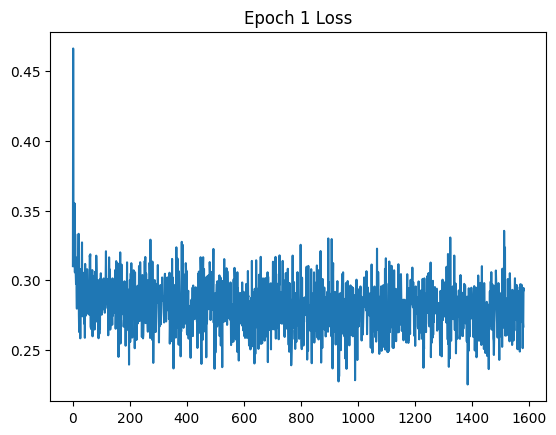

/tmp/ipykernel_485/3889136105.py:29: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Generating images: 100it [00:22,  4.39it/s]


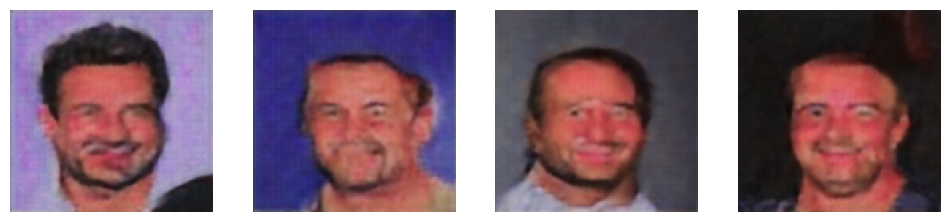

Epoch 2/10


  0%|          | 0/1583 [00:00<?, ?it/s]

Step 0/1583, Loss: 0.2755


  3%|▎         | 51/1583 [07:53<11:15:10, 26.44s/it]

Step 50/1583, Loss: 0.2817


...

 95%|█████████▍| 1500/1583 [3:18:13<08:41,  6.28s/it]

Step 1500/1583, Loss: 0.8204


 98%|█████████▊| 1551/1583 [3:26:14<13:51, 25.97s/it]

Step 1550/1583, Loss: 0.8202


100%|██████████| 1583/1583 [3:29:42<00:00,  7.95s/it]


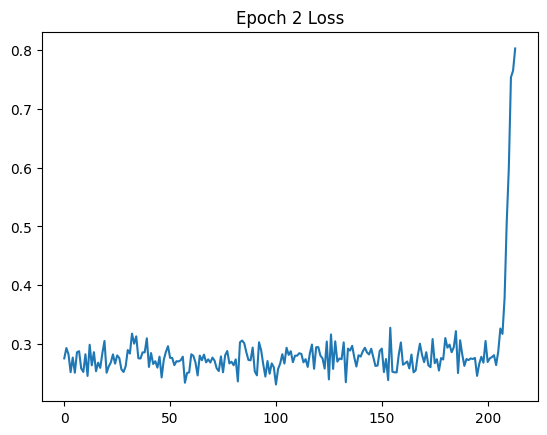

Generating images: 100it [00:20,  4.85it/s]


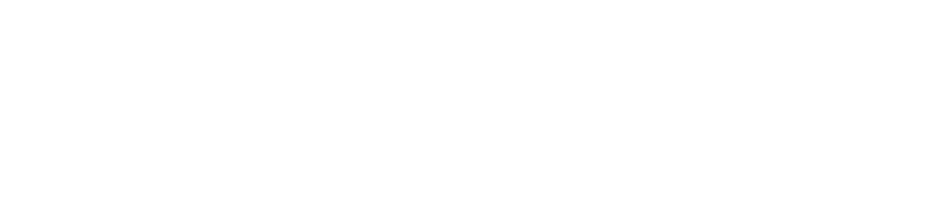

Epoch 3/10


  0%|          | 0/1583 [00:00<?, ?it/s]

Step 0/1583, Loss: 0.8203


  3%|▎         | 51/1583 [07:39<9:51:56, 23.18s/it]

Step 50/1583, Loss: 0.8204


...

Step 800/1583, Loss: 0.8206


 54%|█████▍    | 851/1583 [1:53:14<4:42:53, 23.19s/it]

Step 850/1583, Loss: 0.8203


 57%|█████▋    | 900/1583 [2:00:06<1:31:08,  8.01s/it]


KeyboardInterrupt: 

In [ ]:
EPOCHS = 10

optimizer = torch.optim.AdamW(unet_cond.parameters(), lr=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

for epoch in range(EPOCHS):
    print(f"Epoch {epoch+1}/{EPOCHS}")
    losses = train_one_epoch_with_text(unet_cond, vae, optimizer, dataloader_attr, )
    plt.plot(losses)
    plt.title(f"Epoch {epoch+1} Loss")
    plt.show()
    torch.save(unet_cond.state_dict(), f"checkpoints/unet_cond_epoch_{epoch+1}.pth")

    # Generate images with text conditioning
    generated = generate_images_with_text(unet_cond, vae, "Male Smiling", num_images=4)
    plt.figure(figsize=(12, 6))
    for i, img in enumerate(generated):
        plt.subplot(1, 4, i + 1)
        plt.imshow(img)
        plt.axis('off')
    plt.show()

/tmp/ipykernel_7222/3070816546.py:29: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Generating images: 100it [00:08, 11.79it/s]


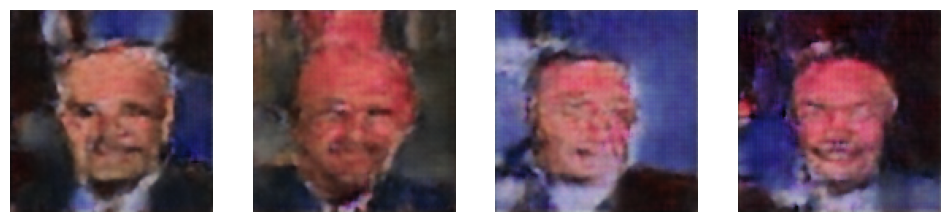

In [25]:
generated = generate_images_with_text(unet_cond, vae, "Bald Man", num_images=4)
plt.figure(figsize=(12, 6))
for i, img in enumerate(generated):
    plt.subplot(1, 4, i + 1)
    plt.imshow(img)
    plt.axis('off')
plt.show()

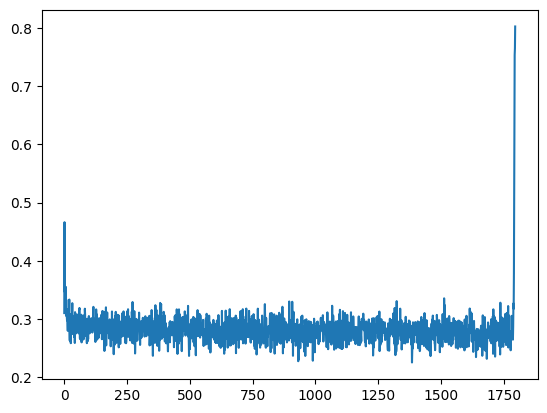

In [24]:
plt.plot(all_losses)

In [24]:
unet_cond_best = UNet2DConditionModel(
    sample_size=32,
    in_channels=3,
    out_channels=3,
    layers_per_block=2,
    block_out_channels=(64, 128, 256, 512),
    down_block_types=(
        "DownBlock2D",
        "DownBlock2D",
        "CrossAttnDownBlock2D",  # Cross-attention block
        "CrossAttnDownBlock2D",  # Cross-attention block
    ),
    up_block_types=(
        "CrossAttnUpBlock2D",    # Cross-attention block
        "CrossAttnUpBlock2D",
        "UpBlock2D",
        "UpBlock2D",
    ),
    cross_attention_dim=512,  # Dimension of the text embedding
).to(device)
unet_cond_best.load_state_dict(torch.load("checkpoints/unet_cond_step_900.pth"))

/tmp/ipykernel_490/66869802.py:21: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  unet_cond_best.load_state_dict(torch.load("checkpoints/unet_cond_step_900.pth"))


<All keys matched successfully>

/tmp/ipykernel_490/3889136105.py:29: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Generating images: 100it [00:09, 10.07it/s]


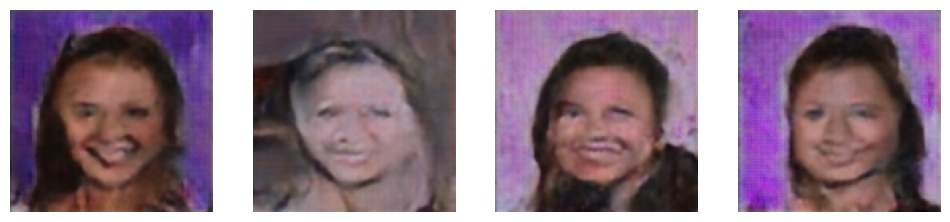

In [25]:
generated = generate_images_with_text(unet_cond_best, vae, "Smiling Woman", num_images=4)
plt.figure(figsize=(12, 6))
for i, img in enumerate(generated):
    plt.subplot(1, 4, i + 1)
    plt.imshow(img)
    plt.axis('off')
plt.show()

In [15]:
def text_to_image(text_prompt, num_images=1, guidance_scale=3.0):
    """
    Helper function to generate images from text prompts 
    and display them in a grid.
    
    Args:
        text_prompt (str): The text description to generate images for
        num_images (int): Number of images to generate
        guidance_scale (float): Controls how strongly the generation follows the text
    """
    print(f"Generating {num_images} images for prompt: '{text_prompt}'")
    
    # Load models if needed
    if not 'vae' in globals() or not 'unet_cond' in globals():
        print("Loading models...")
        vae = torch.load("vae.pth").to(device)
        unet_cond = torch.load("unet_cond.pth").to(device)
    
    # Generate the images
    with torch.no_grad():
        generated_images = generate_images_with_text(
            unet_cond, vae, text_prompt, 
            num_images=num_images,
            guidance_scale=guidance_scale
        )
    
    # Display the images in a grid
    cols = min(4, num_images)
    rows = (num_images + cols - 1) // cols
    
    plt.figure(figsize=(cols * 3, rows * 3))
    for i, img in enumerate(generated_images):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)
        plt.axis('off')
    
    plt.suptitle(f"Generated images for: '{text_prompt}'", fontsize=16)
    plt.tight_layout()
    plt.show()
    
    return generated_images

In [16]:
def setup_training_with_scheduler(unet, vae, num_epochs=10, base_lr=1e-4, scheduler_type='cosine'):
    """
    Setup training with a learning rate scheduler.
    
    Args:
        unet (torch.nn.Module): The UNet model to train
        vae (torch.nn.Module): VAE model for encoding/decoding
        num_epochs (int): Number of epochs to train for
        base_lr (float): Base learning rate to start with
        scheduler_type (str): Type of scheduler ('cosine', 'onecycle', or 'plateau')
    
    Returns:
        optimizer: The configured optimizer
        scheduler: The configured learning rate scheduler
    """
    # Create optimizer
    optimizer = torch.optim.AdamW(unet.parameters(), lr=base_lr)
    
    # Calculate total steps for epoch-based schedulers
    steps_per_epoch = len(dataloader_attr)
    total_steps = steps_per_epoch * num_epochs
    
    # Create the appropriate scheduler
    if scheduler_type == 'cosine':
        # Cosine annealing gradually reduces learning rate following a cosine curve
        scheduler = CosineAnnealingLR(
            optimizer, 
            T_max=total_steps,
            eta_min=base_lr/100  # Minimum learning rate (1% of base_lr)
        )
    elif scheduler_type == 'onecycle':
        # One-cycle learning rate: quick warmup, then annealing
        scheduler = OneCycleLR(
            optimizer,
            max_lr=base_lr*10,  # Peak learning rate
            total_steps=total_steps,
            pct_start=0.1,  # Spend 10% of training warming up
            div_factor=10,  # Initial LR = max_lr/10
            final_div_factor=100  # Final LR = max_lr/1000
        )
    elif scheduler_type == 'plateau':
        # Reduce LR when loss plateaus
        scheduler = ReduceLROnPlateau(
            optimizer,
            mode='min',
            factor=0.5,  # Reduce LR by half when plateauing
            patience=500,  # Wait for 500 steps before reducing
            min_lr=base_lr/100
        )
    else:
        raise ValueError(f"Unknown scheduler type: {scheduler_type}")
    
    return optimizer, scheduler

In [18]:
def train_diffusion_with_scheduler(unet, vae, num_epochs=10, scheduler_type='cosine', base_lr=1e-4):
    """
    Full training function with learning rate scheduler to train the text-conditioned diffusion model.
    
    Args:
        unet (UNet2DConditionModel): The model to train
        vae (SpatialVAE): The VAE for encoding/decoding images
        num_epochs (int): Number of epochs to train
        scheduler_type (str): Type of scheduler to use ('cosine', 'onecycle', or 'plateau')
        base_lr (float): Initial learning rate
    
    Returns:
        tuple: Training history (losses, learning rates)
    """
    print(f"Setting up training with {scheduler_type} learning rate scheduler...")
    
    # Set up optimizer and scheduler
    optimizer, scheduler = setup_training_with_scheduler(
        unet, vae, 
        num_epochs=num_epochs, 
        base_lr=base_lr,
        scheduler_type=scheduler_type
    )
    
    # For tracking metrics
    epoch_losses = []
    learning_rates = []
    
    # Track validation loss for plateau scheduler
    best_val_loss = float('inf')
    plateau_tracker = []
    
    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1}/{num_epochs}")
        
        # Train for one epoch
        if scheduler_type == 'plateau':
            # For plateau scheduler, we need to step based on validation loss
            losses = train_one_epoch_with_text(unet, vae, optimizer, dataloader_attr, device, noise_scheduler, all_losses)
            val_loss = estimate_loss(unet, vae, dataloader_attr)
            scheduler.step(val_loss)
            plateau_tracker.append(val_loss)
        else:
            # For step-based schedulers, the scheduler is already stepped in the training loop
            losses = train_one_epoch_with_text(unet, vae, optimizer, dataloader_attr, device, noise_scheduler, all_losses)
        
        # Save the current learning rate
        current_lr = optimizer.param_groups[0]['lr']
        learning_rates.append(current_lr)
        
        # Calculate average loss for this epoch
        avg_loss = sum(losses) / len(losses)
        epoch_losses.append(avg_loss)
        
        # Display loss curve
        plt.figure(figsize=(12, 5))
        plt.subplot(1, 2, 1)
        plt.plot(losses)
        plt.title(f"Epoch {epoch+1} Loss")
        plt.subplot(1, 2, 2)
        plt.plot(learning_rates)
        plt.title("Learning Rate")
        plt.tight_layout()
        plt.show()
        
        # Save model checkpoint
        torch.save(unet.state_dict(), f"checkpoints/unet_cond_epoch_{epoch+1}.pth")
        
        # Generate sample images to visualize progress
        print("Generating sample images...")
        generated = generate_images_with_text(unet, vae, "Blonde Hair", num_images=2, guidance_scale=3.0)
        plt.figure(figsize=(8, 4))
        for i, img in enumerate(generated):
            plt.subplot(1, 2, i + 1)
            plt.imshow(img)
            plt.axis('off')
        plt.suptitle(f"Epoch {epoch+1}: 'Blonde Hair'")
        plt.show()
        
        generated = generate_images_with_text(unet, vae, "Male Smiling", num_images=2, guidance_scale=3.0)
        plt.figure(figsize=(8, 4))
        for i, img in enumerate(generated):
            plt.subplot(1, 2, i + 1)
            plt.imshow(img)
            plt.axis('off')
        plt.suptitle(f"Epoch {epoch+1}: 'Male Smiling'")
        plt.show()
        
        # Check if this is the best model so far
        current_val_loss = estimate_loss(unet, vae, dataloader_attr, device, noise_scheduler, clip_tokenizer, clip_text_encoder)
        if current_val_loss < best_val_loss:
            best_val_loss = current_val_loss
            torch.save(unet.state_dict(), "checkpoints/unet_cond_best.pth")
            print(f"New best model saved! Validation loss: {best_val_loss:.6f}")
    
    # Plot final learning curve
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epoch_losses)
    plt.title("Epoch Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    
    plt.subplot(1, 2, 2)
    plt.plot(learning_rates)
    plt.title("Learning Rate")
    plt.xlabel("Epoch")
    plt.ylabel("Learning Rate")
    
    plt.tight_layout()
    plt.show()
    
    print("Training complete!")
    return epoch_losses, learning_rates

In [19]:
unet_cond = UNet2DConditionModel(
    sample_size=32,
    in_channels=3,
    out_channels=3,
    # layers_per_block=2,
    block_out_channels=(128, 256, 512),
    down_block_types=(
        # "DownBlock2D",
        "DownBlock2D",
        "CrossAttnDownBlock2D",  # Cross-attention block
        "CrossAttnDownBlock2D",  # Cross-attention block
    ),
    up_block_types=(
        "CrossAttnUpBlock2D",    # Cross-attention block
        "CrossAttnUpBlock2D",
        "UpBlock2D",
        # "UpBlock2D",
    ),
    cross_attention_dim=512,  # Dimension of the text embedding
).to(device)

In [20]:
train_diffusion_with_scheduler(
    unet_cond, vae, 
    num_epochs=10, 
    scheduler_type='plateau',
    base_lr=1e-4
)

Setting up training with plateau learning rate scheduler...
Epoch 1/10


TypeError: train_one_epoch_with_text() missing 2 required positional arguments: 'clip_tokenizer' and 'clip_text_encoder'